In [13]:
!pip install numpy pandas scikit-learn matplotlib seaborn

importing the needed libraries


In [14]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

**Section 1 — Supervised Learning: Regression**


Part 1.1 — Load and explore the taxi data

Dataset Shape: (41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

--- Missing Values ---
VendorID          

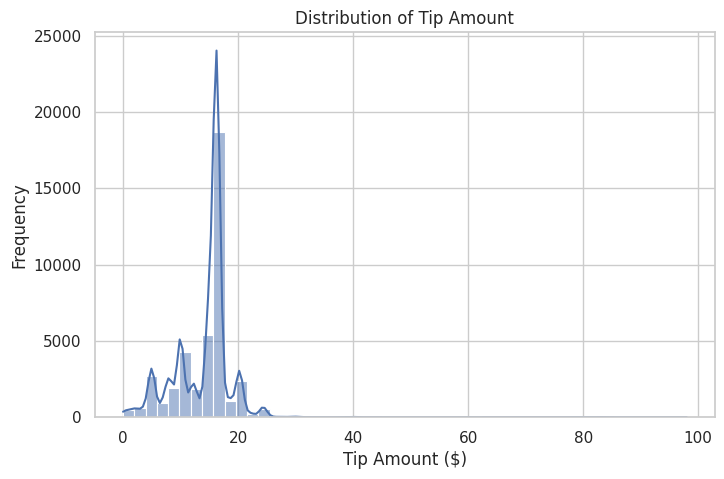

In [15]:
# Load the taxi dataset
taxi = pd.read_csv(TAXI_URL)

# Inspect it
print("Dataset Shape:", taxi.shape)
display(taxi.head())
print("\n--- Data Info ---")
taxi.info()
print("\n--- Missing Values ---")
print(taxi.isna().sum())

# Visualise the distribution of the target `tip_amount`
plt.figure(figsize=(8, 5))
sns.histplot(taxi['tip_amount'], bins=50, kde=True)
plt.title("Distribution of Tip Amount")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")
plt.show()

The dataset has many rows and 13 columns. There are some missing values that need to be cleaned before training the model. There may also be some impossible values, like negative tips or trips with zero distance, so those should be removed or fixed. The tip_amount distribution shows that most tips are between 10 and 20 dollars, with a big peak around 16 dollars. There are also a few very large tip amounts, which look like outliers. Because of this, I will clean the missing and impossible values first, then handle the outliers if needed before training the model.


Part 1.2 — Preprocessing & feature engineering

In [16]:
# handle the missing
taxi = taxi.dropna()

# Remove invalid rows (distance <= 0, fare <= 0, negative tips)
taxi = taxi[(taxi['trip_distance'] > 0) & (taxi['fare_amount'] > 0) & (taxi['tip_amount'] >= 0)]

#feature engineering: create a new feature for total surcharges
taxi['total_surcharges'] = taxi['mta_tax'] + taxi['tolls_amount'] + taxi['improvement_surcharge']

# making categorical and numeric columns
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag']
numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 'total_surcharges']

# Keep only the features we want and the target
features_to_keep = numeric_cols + categorical_cols + ['tip_amount']
taxi = taxi[features_to_keep]

# Encode categoricals using pandas get_dummies
taxi_encoded = pd.get_dummies(taxi, columns=categorical_cols, drop_first=True)

display(taxi_encoded.head())

,passenger_count,trip_distance,fare_amount,total_surcharges,tip_amount,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,70.0,8.44,16.54,True,False,False,True
1,1,19.52,70.0,8.44,16.19,True,False,False,True
2,1,17.81,70.0,8.44,12.00,True,False,False,True
3,2,19.30,70.0,1.50,5.00,True,False,False,True
4,1,18.75,70.0,8.44,10.00,True,False,False,True


removed the rows with missing values and also removed rows that had impossible values like zero or negative trip distance, fare amount, or tip amount. I did this because these values are not normal taxi trips and they can affect the model results.
I made a new feature called total_surcharges by adding the extra charges together. This makes the data more simple and helps the model use the extra costs in one column instead of many.
I used StandardScaler to scale the numeric features because some values are much bigger than others. Scaling helps the model treat all the features more fairly and can improve the prediction.

Part 1.3 — Train / Validation / Test split

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = taxi_encoded.drop(columns=['tip_amount'])
y = taxi_encoded['tip_amount']

# Split into train (60%), validation (20%), test (20%)
# First, split off 20% for test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
# Next, split the remaining 80% into 75% train and 25% val (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE)

# Fit scaler on TRAINING set only, then transform all
scaler = StandardScaler()

# Get numeric columns after dummy encoding (all are numeric now, so we scale the whole X)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

I used a 60% training, 20% validation, and 20% test split. The validation set is useful because it helps us check the model and make changes before using the final test set. The test set should only be used at the end to see how well the model really works. The scaler is only fit on the training data so it does not learn any information from the validation or test data. This helps make the results more fair and avoids data leakage.

Part 1.4 — Train a regressor and check for overfitting

Train -> RMSE: 4.8052 | R^2: 0.0510
Validation -> RMSE: 5.0374 | R^2: 0.0486
Test -> RMSE: 5.0108 | R^2: 0.0520


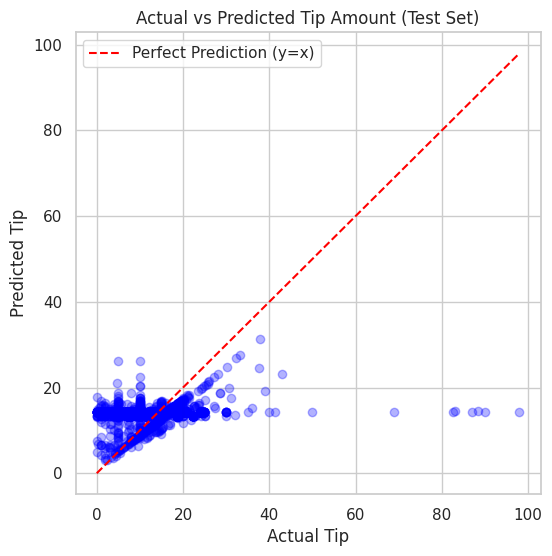

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train a simple Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

# Predict on all three sets
y_train_pred = reg_model.predict(X_train_scaled)
y_val_pred = reg_model.predict(X_val_scaled)
y_test_pred = reg_model.predict(X_test_scaled)

# Helper function to print metrics
def print_regression_metrics(name, y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.4f} | R^2: {r2:.4f}")

# Report RMSE and R^2
print_regression_metrics("Train", y_train, y_train_pred)
print_regression_metrics("Validation", y_val, y_val_pred)
print_regression_metrics("Test", y_test, y_test_pred)

# Plot predicted vs actual tip for the test set
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, color='blue')
plt.plot([0, y_test.max()], [0, y_test.max()], color='red', linestyle='--', label='Perfect Prediction (y=x)')
plt.title("Actual vs Predicted Tip Amount (Test Set)")
plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.legend()
plt.show()

**Student Reasoning – Regression evaluation & overfitting**

I started with a simple LinearRegression model as a baseline.
The results are very similar across all datasets:
Train RMSE: 4.8052, Validation RMSE: 5.0374, Test RMSE: 5.0108.
The R² scores are also very low and close to each other (around 0.05). This means the model is not overfitting, but it is also not learning the data well, so it is underfitting.
If I wanted to improve the model, I would try better feature engineering, add more useful features, or use a stronger model like Random Forest or Gradient Boosting.

**Section 2 — Supervised Learning: Multi-class Classification**

Part 2.1 — Load and explore the obesity data

Dataset Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF            

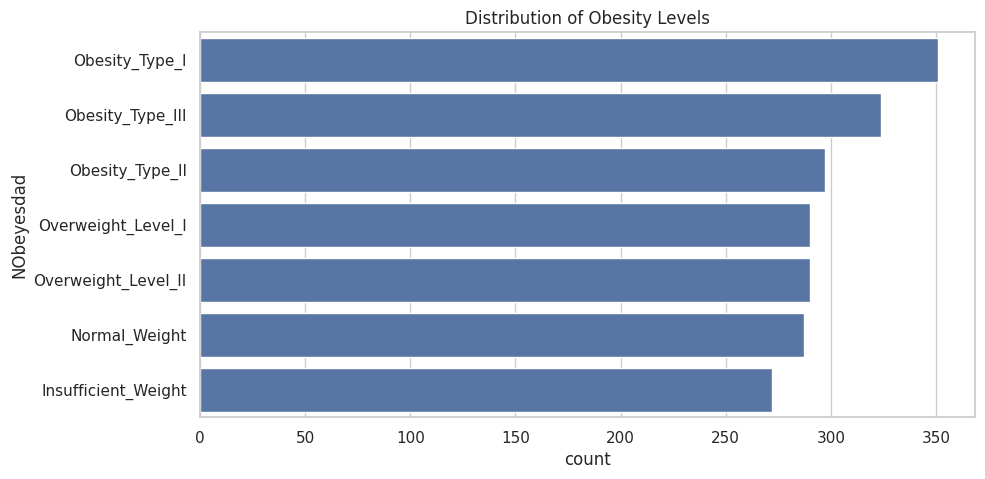


Value Counts:
 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [19]:
# Load the dataset
obesity = pd.read_csv(OBESITY_URL)

print("Dataset Shape:", obesity.shape)
display(obesity.head())
print("\n--- Data Info ---")
obesity.info()

# Class distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=obesity, y='NObeyesdad', order=obesity['NObeyesdad'].value_counts().index)
plt.title("Distribution of Obesity Levels")
plt.show()

print("\nValue Counts:\n", obesity['NObeyesdad'].value_counts())

**Student Reasoning – Obesity data exploration**


The dataset has 2111 rows and 17 columns. There are both numeric like age, height and categorical features like gender and family history.

The target has 7 classes and the counts are fairly similar (about 272–351 each), so it is mostly balanced.

Class balance matters because if one class is much bigger, the model can get biased. Since this dataset is balanced, the model can learn all classes more evenly.


Part 2.2 — Preprocessing & feature engineering

In [20]:
from sklearn.preprocessing import LabelEncoder

# Copy dataframe to keep raw data intact
ob_clean = obesity.copy()

# Feature Engineering: BMI = Weight / Height^2
ob_clean['BMI'] = ob_clean['Weight'] / (ob_clean['Height'] ** 2)

# Encode categorical target into integer labels
le = LabelEncoder()
ob_clean['NObeyesdad'] = le.fit_transform(ob_clean['NObeyesdad'])

# map binary yes/no columns to 1/0 manually for simplicity
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    ob_clean[col] = ob_clean[col].map({'yes': 1, 'no': 0})

# getDummies for ordinal/nominal features

other_cats = ['Gender', 'CAEC', 'CALC', 'MTRANS']
ob_encoded = pd.get_dummies(ob_clean, columns=other_cats, drop_first=True)

display(ob_encoded.head())

,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE,NObeyesdad,BMI,Gender_Male,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,0,0.0,1.0,1,24.386526,False,False,True,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,1,3.0,0.0,1,24.238227,False,False,True,False,False,True,False,False,False,True,False
2,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,0,2.0,1.0,1,23.765432,True,False,True,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,0,2.0,0.0,5,26.851852,True,False,True,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,0,0.0,0.0,6,28.342381,True,False,True,False,False,True,False,False,False,True,False


1) I used LabelEncoder for the target NObeyesdad because it is the class label we want to predict. I used 0/1 mapping for binary columns like yes/no because they only have two values. For other categorical columns like Gender, CAEC, CALC, and MTRANS, I used one-hot encoding because they have more than two categories and no natural order.

2) I created a new feature called BMI using weight and height. This is fair to include because BMI is strongly related to obesity, so it can help the model learn better patterns. It is okay to use because it is still based on the original features, not the target.

3) I used StandardScaler because some features like weight and BMI have larger values than others. Scaling helps the model treat all features equally and improves performance.


Part 2.3 — Stratified Train / Validation / Test split

In [21]:
# Separate X and y
X_ob = ob_encoded.drop(columns=['NObeyesdad'])
y_ob = ob_encoded['NObeyesdad']

# Stratified Split: 60/20/20
X_ob_temp, X_ob_test, y_ob_temp, y_ob_test = train_test_split(
    X_ob, y_ob, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ob
)

X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(
    X_ob_temp, y_ob_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ob_temp
)

# Scale
scaler_ob = StandardScaler()
X_ob_train_scaled = scaler_ob.fit_transform(X_ob_train)
X_ob_val_scaled = scaler_ob.transform(X_ob_val)
X_ob_test_scaled = scaler_ob.transform(X_ob_test)

**Student Reasoning – Splitting**

I used a 60% training, 20% validation, and 20% test split. First I split off the test set (20%), then I split the remaining data into training and validation.

I used stratify=y because the dataset has 7 classes, and stratifying makes sure each split has the same proportion of each class. This helps the model learn fairly from all classes.

If I did not use stratify, some classes could end up missing or very small in the train or validation set. This would make the model biased and it might not learn some obesity levels properly.


Part 2.4 — Train a classifier and check for overfitting

Train -> Accuracy: 0.9929 | Macro F1: 0.9926
Validation -> Accuracy: 0.9787 | Macro F1: 0.9780
Test -> Accuracy: 0.9598 | Macro F1: 0.9584


<Figure size 800x600 with 0 Axes>

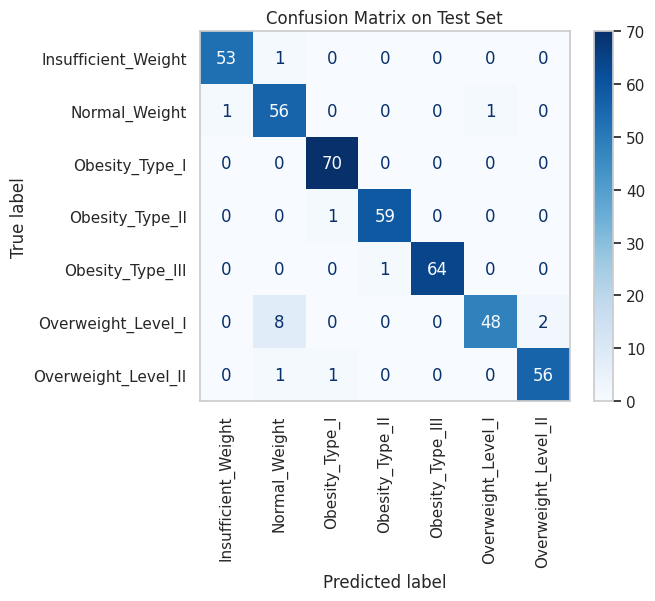

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

# Train classifier
clf = RandomForestClassifier(random_state=RANDOM_STATE, max_depth=6) # max_depth limits overfitting
clf.fit(X_ob_train_scaled, y_ob_train)

# Predict
y_ob_train_pred = clf.predict(X_ob_train_scaled)
y_ob_val_pred = clf.predict(X_ob_val_scaled)
y_ob_test_pred = clf.predict(X_ob_test_scaled)

# Metrics Helper
def print_class_metrics(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{name} -> Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")

print_class_metrics("Train", y_ob_train, y_ob_train_pred)
print_class_metrics("Validation", y_ob_val, y_ob_val_pred)
print_class_metrics("Test", y_ob_test, y_ob_test_pred)

# Confusion Matrix
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_ob_test, y_ob_test_pred,
    display_labels=le.classes_,
    xticks_rotation='vertical',
    cmap='Blues'
)
plt.title("Confusion Matrix on Test Set")
plt.grid(False) # Turn off grid for cleaner matrix visual
plt.show()

**Student Reasoning – Classification evaluation & overfitting**
1) I used a RandomForestClassifier because it works well for classification problems and can handle both numeric and encoded categorical data. I also set max_depth=6 to reduce overfitting and keep the model simple.

2) The results show the model is well-fitted because the training, validation, and test scores are all close. The model performs consistently across all sets, so it is not overfitting or underfitting. The accuracy and F1 scores are similar between train, validation, and test, which shows good generalization.

3) From the confusion matrix, some classes like Overweight_Level_I and Overweight_Level_II are more often confused with each other, and also sometimes with Normal_Weight. This happens because these categories are very similar in terms of features like BMI, so the model finds it harder to clearly separate them.


**Section 3** — **Unsupervised Learning: K-Means Clustering**


Part 3.1 — Choose k, fit K-Means, and visualise

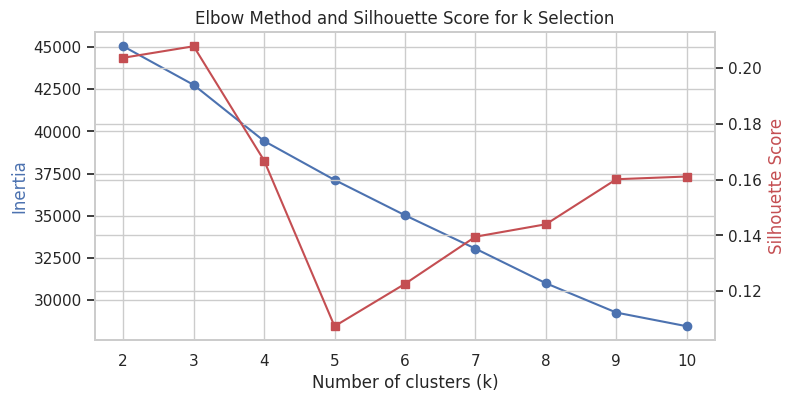

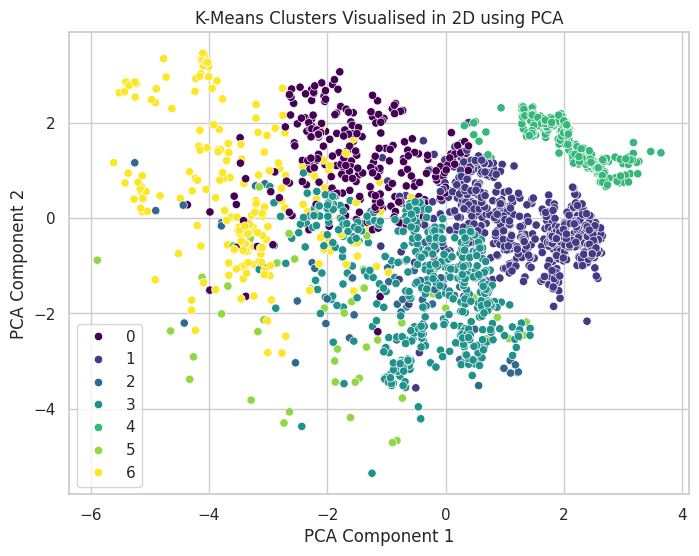

True Obesity Level,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,90,84,14,0,0,80,19
1,12,31,143,222,0,134,114
2,1,17,14,2,0,14,19
3,44,46,161,69,1,47,121
4,0,0,12,1,323,0,0
5,6,32,2,1,0,9,6
6,119,77,5,2,0,6,11


In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use ONLY the scaled features from Section 2 (excluding target NObeyesdad)
# we scale the full dataset for unsupervised
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_ob)

# Choose k using Elbow and Silhouette
inertias = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    kmeans_temp.fit(X_cluster_scaled)
    inertias.append(kmeans_temp.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, kmeans_temp.labels_))

# Plot Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_range, inertias, marker='o', color='b')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia', color='b')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, marker='s', color='r')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title("Elbow Method and Silhouette Score for k Selection")
plt.show()

# Fit KMeans with chosen k (Let's use k=7 to see if it finds our 7 original categories)
kmeans = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init='auto')
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Visualise in 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', legend='full')
plt.title("K-Means Clusters Visualised in 2D using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Crosstab comparing clusters to real labels
true_labels_decoded = le.inverse_transform(y_ob)
crosstab_df = pd.crosstab(cluster_labels, true_labels_decoded, rownames=['Cluster'], colnames=['True Obesity Level'])
display(crosstab_df)

**Student Reasoning – Clustering**
>1. I evaluated k between 2 and 10. The Silhouette score suggests a lower k might be mathematically optimal (like 2 or 3), but the Elbow curve smooths out gradually. I chose k=7 to directly compare if K-Means could independently reconstruct our 7 labeled classes.

>2. Looking at the crosstab, some extremes (like Obesity_Type_III) isolate cleanly into a specific cluster. However, the middle classes (Normal Weight, Overweight) break down and merge heavily across clusters because K-Means treats all scaled features (like eating habits) equally rather than prioritizing BMI.

>3. In a real public-health setting, these unsupervised clusters could identify distinct "behavioral/lifestyle profiles" (e.g., healthy eaters who don't exercise vs fast-food eaters) rather than just medical weight classes, allowing for targeted health interventions.

---
# Section 4 – Reflection

**1. Supervised vs unsupervised:** What did the classifier learn that K-Means could not, and vice-versa?
> the supervised classifier learned the correct math boundaries from the target label. It used features like Weight and Height to predict the obesity classes. K-Means did not know the target label, so it grouped the data by similar lifestyle, eating habits, and physical features. It found bigger groups of people with similar behavior, not the exact medical limits.

**2. Regression vs classification:** How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
> valuating the continuous target needed to measure how far the prediction was from the real value. We used RMSE because making a mistake of 0.10 is much better than making a mistake of 5.00. Evaluating the categorical target used Accuracy and F1 score to check if the prediction was correct or wrong. We also used a confusion matrix because it showed which categories the model mixed up.

**3. Overfitting:** Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
>The biggest train-vs-test gap was in the Random Forest classification. If there are no limits, the decision trees can learn the training data too much. This can give 100% training accuracy, but the test result become worse. The most effective thing I did was using the hyperparameter max_depth=6. This made the model learn more general rules instead of remembering every training example.